# OM_BKK_DATA Historical Weather Analysis

Exploratory analysis for the PostgreSQL table `"OM_BKK_DATA"`, loaded from the Open-Meteo Historical Weather API using the coordinates in `"Bangkok_Grid_9km"`.

Main goals:
- Check table coverage and missing values
- Understand rainfall patterns by hour, month, and grid point
- Compare weather variables against precipitation
- Create reusable daily/monthly summary datasets for modelling

## 1. Setup

Run the install cell only if your notebook kernel does not already have these packages.

In [1]:
# Optional: uncomment if needed.
# %pip install pandas psycopg2-binary matplotlib seaborn numpy

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Connect To PostgreSQL

Defaults mirror the project scripts. Override with environment variables if needed.

In [3]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
GRID_TABLE = '"Bangkok_Grid_9km"'

conn = psycopg2.connect(**DB_CONFIG)

def sql(query, params=None):
    return pd.read_sql_query(query, conn, params=params)

print("Connected")

Connected


## 3. Table Health

In [4]:
summary = sql(f'''
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT grid_number) AS grid_count,
    MIN(local_forecast_time) AS min_time,
    MAX(local_forecast_time) AS max_time,
    COUNT(DISTINCT local_forecast_time) AS distinct_hours,
    COUNT(*)::numeric / NULLIF(COUNT(DISTINCT grid_number), 0) AS rows_per_grid
FROM {TABLE_NAME};
''')
summary

,row_count,grid_count,min_time,max_time,distinct_hours,rows_per_grid
0,2454144,56,2021-07-20,2026-07-19 23:00:00,43824,43824.000


In [5]:
columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "dew_point_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
]

missing_expr = ",\n    ".join(
    f"COUNT(*) FILTER (WHERE {column} IS NULL) AS missing_{column}"
    for column in columns
)
missing = sql(f"""
SELECT
    COUNT(*) AS row_count,
    {missing_expr}
FROM {TABLE_NAME};
""")
missing.T.rename(columns={0: "count"})

,count
row_count,2454144
missing_temperature_2m,0
missing_relative_humidity_2m,0
missing_pressure_msl,0
missing_surface_pressure,0
missing_dew_point_2m,0
missing_precipitation,0
missing_cloud_cover,0
missing_wind_speed_10m,0
missing_wind_direction_10m,0


In [6]:
coverage_by_year = sql(f'''
SELECT
    DATE_TRUNC('year', local_forecast_time)::date AS year,
    COUNT(*) AS rows,
    COUNT(DISTINCT grid_number) AS grids,
    COUNT(DISTINCT local_forecast_time) AS hours
FROM {TABLE_NAME}
GROUP BY 1
ORDER BY 1;
''')
coverage_by_year

,year,rows,grids,hours
0,2021-01-01,221760,56,3960
1,2022-01-01,490560,56,8760
2,2023-01-01,490560,56,8760
3,2024-01-01,491904,56,8784
4,2025-01-01,490560,56,8760
5,2026-01-01,268800,56,4800


## 4. Grid Overview

In [7]:
grid = sql(f'''
SELECT grid_number, grid_row, grid_column, latitude, longitude
FROM {GRID_TABLE}
ORDER BY grid_number;
''')
grid.head(), grid.shape

(   grid_number  grid_row  grid_column  latitude  longitude
 0            1         1            1    13.494    100.327
 1            2         1            2    13.494    100.410
 2            3         1            3    13.494    100.493
 3            4         1            4    13.494    100.577
 4            5         1            5    13.494    100.660,
 (56, 5))

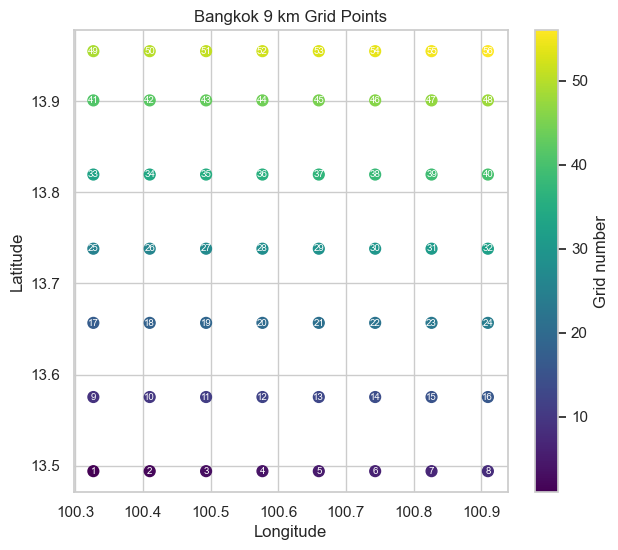

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(grid["longitude"], grid["latitude"], c=grid["grid_number"], cmap="viridis", s=60)
for _, row in grid.iterrows():
    ax.text(row["longitude"], row["latitude"], str(int(row["grid_number"])), fontsize=7, ha="center", va="center", color="white")
ax.set_title("Bangkok 9 km Grid Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(scatter, ax=ax, label="Grid number")
plt.show()

## 5. Daily Weather Summary

This aggregates hourly data into daily values by grid point. It is small enough to work with comfortably in memory.

In [9]:
daily = sql(f'''
SELECT
    grid_number,
    grid_row,
    grid_column,
    latitude,
    longitude,
    local_forecast_time::date AS date,
    AVG(temperature_2m) AS temp_mean,
    MIN(temperature_2m) AS temp_min,
    MAX(temperature_2m) AS temp_max,
    AVG(relative_humidity_2m) AS humidity_mean,
    AVG(dew_point_2m) AS dew_point_mean,
    AVG(pressure_msl) AS pressure_msl_mean,
    AVG(surface_pressure) AS surface_pressure_mean,
    SUM(precipitation) AS precipitation_sum,
    MAX(precipitation) AS precipitation_hourly_max,
    COUNT(*) FILTER (WHERE precipitation >= 0.1) AS rain_hours,
    AVG(cloud_cover) AS cloud_cover_mean,
    AVG(wind_speed_10m) AS wind_speed_mean
FROM {TABLE_NAME}
GROUP BY 1,2,3,4,5,6
ORDER BY date, grid_number;
''')

daily["date"] = pd.to_datetime(daily["date"])
daily["month"] = daily["date"].dt.month
daily["year"] = daily["date"].dt.year
daily["is_rain_day"] = daily["precipitation_sum"] >= 0.1
daily.head()

,grid_number,grid_row,grid_column,latitude,longitude,date,temp_mean,temp_min,temp_max,humidity_mean,dew_point_mean,pressure_msl_mean,surface_pressure_mean,precipitation_sum,precipitation_hourly_max,rain_hours,cloud_cover_mean,wind_speed_mean,month,year,is_rain_day
0,1,1,1,13.494,100.327,2021-07-20,27.646,26.400,29.500,82.667,24.400,1006.879,1006.679,10.800,2.400,20,94.583,16.954,7,2021,True
1,2,1,2,13.494,100.410,2021-07-20,27.908,26.500,29.400,80.875,24.300,1006.942,1006.942,6.900,2.000,12,91.583,20.208,7,2021,True
2,3,1,3,13.494,100.493,2021-07-20,27.908,26.500,29.400,80.792,24.300,1006.942,1006.942,6.900,2.000,12,91.583,20.208,7,2021,True
3,4,1,4,13.494,100.577,2021-07-20,28.083,26.500,29.700,79.792,24.242,1006.987,1006.987,5.500,1.400,14,87.500,20.208,7,2021,True
4,5,1,5,13.494,100.660,2021-07-20,28.083,26.500,29.700,79.792,24.242,1006.987,1006.987,5.500,1.400,14,87.500,20.208,7,2021,True


In [10]:
daily.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
grid_number,102256.000,NaN,NaN,NaN,28.500,1.000,14.750,28.500,42.250,56.000,16.163
grid_row,102256.000,NaN,NaN,NaN,4.000,1.000,2.000,4.000,6.000,7.000,2.000
grid_column,102256.000,NaN,NaN,NaN,4.500,1.000,2.750,4.500,6.250,8.000,2.291
latitude,102256.000,NaN,NaN,NaN,13.734,13.494,13.575,13.738,13.901,13.955,0.157
longitude,102256.000,NaN,NaN,NaN,100.618,100.327,100.473,100.618,100.764,100.910,0.191
date,102256,NaN,NaN,NaN,2024-01-18 12:00:00,2021-07-20 00:00:00,2022-10-19 00:00:00,2024-01-18 12:00:00,2025-04-19 00:00:00,2026-07-19 00:00:00,NaN
temp_mean,102256.000,NaN,NaN,NaN,27.972,19.192,26.963,27.971,29.083,34.087,1.787
temp_min,102256.000,NaN,NaN,NaN,24.673,13.700,23.600,25.000,26.100,31.000,2.298
temp_max,102256.000,NaN,NaN,NaN,32.050,24.400,30.700,31.900,33.300,41.900,2.137
humidity_mean,102256.000,NaN,NaN,NaN,75.153,38.167,69.417,76.833,82.458,97.125,9.649


## 6. Rainfall Time Series

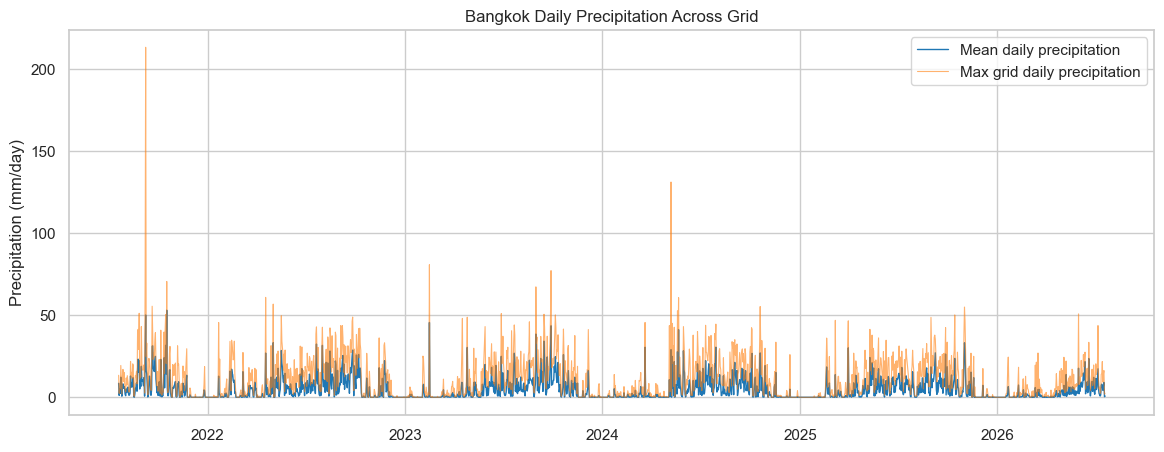

In [11]:
city_daily = (
    daily.groupby("date", as_index=False)
    .agg(
        precipitation_mean=("precipitation_sum", "mean"),
        precipitation_max=("precipitation_sum", "max"),
        rain_grid_share=("is_rain_day", "mean"),
        temp_mean=("temp_mean", "mean"),
        humidity_mean=("humidity_mean", "mean"),
        cloud_cover_mean=("cloud_cover_mean", "mean"),
        wind_speed_mean=("wind_speed_mean", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(city_daily["date"], city_daily["precipitation_mean"], linewidth=1, label="Mean daily precipitation")
ax.plot(city_daily["date"], city_daily["precipitation_max"], linewidth=0.8, alpha=0.6, label="Max grid daily precipitation")
ax.set_title("Bangkok Daily Precipitation Across Grid")
ax.set_ylabel("Precipitation (mm/day)")
ax.legend()
plt.show()

In [12]:
top_rain_days = city_daily.sort_values("precipitation_max", ascending=False).head(20)
top_rain_days

,date,precipitation_mean,precipitation_max,rain_grid_share,temp_mean,humidity_mean,cloud_cover_mean,wind_speed_mean
50,2021-09-08,50.164,213.300,1.000,26.157,89.898,99.518,7.254
1022,2024-05-07,29.023,131.200,1.000,28.590,84.469,81.092,10.283
575,2023-02-15,45.596,80.800,1.000,25.659,87.341,70.164,9.025
800,2023-09-28,43.568,77.200,1.000,26.585,88.213,99.156,14.951
49,2021-09-07,26.512,70.900,1.000,26.826,86.594,99.547,9.160
89,2021-10-17,53.095,70.600,1.000,24.014,92.702,100.000,7.791
772,2023-08-31,38.550,67.300,1.000,28.459,83.196,95.753,6.930
272,2022-04-18,26.979,60.900,1.000,27.390,83.560,91.618,6.176
1036,2024-05-21,41.212,60.700,1.000,28.588,85.875,99.958,6.885
286,2022-05-02,33.295,56.800,1.000,26.113,79.768,99.293,12.485


## 7. Seasonality

In [13]:
monthly = (
    daily.groupby(["year", "month"], as_index=False)
    .agg(
        precipitation_sum=("precipitation_sum", "sum"),
        precipitation_mean=("precipitation_sum", "mean"),
        rain_day_share=("is_rain_day", "mean"),
        temp_mean=("temp_mean", "mean"),
        humidity_mean=("humidity_mean", "mean"),
        cloud_cover_mean=("cloud_cover_mean", "mean"),
        wind_speed_mean=("wind_speed_mean", "mean"),
    )
)
monthly["month_name"] = pd.to_datetime(monthly["month"], format="%m").dt.month_name().str.slice(0, 3)
monthly.head()

,year,month,precipitation_sum,precipitation_mean,rain_day_share,temp_mean,humidity_mean,cloud_cover_mean,wind_speed_mean,month_name
0,2021,7,3973.100,5.912,1.000,28.071,82.016,92.105,12.138,Jul
1,2021,8,13072.000,7.530,0.966,28.080,80.791,89.316,9.480,Aug
2,2021,9,22008.000,13.100,0.986,27.000,85.938,91.723,7.546,Sep
3,2021,10,16086.600,9.266,0.931,26.945,84.535,84.899,7.144,Oct
4,2021,11,5703.600,3.395,0.737,26.668,78.454,77.350,7.525,Nov


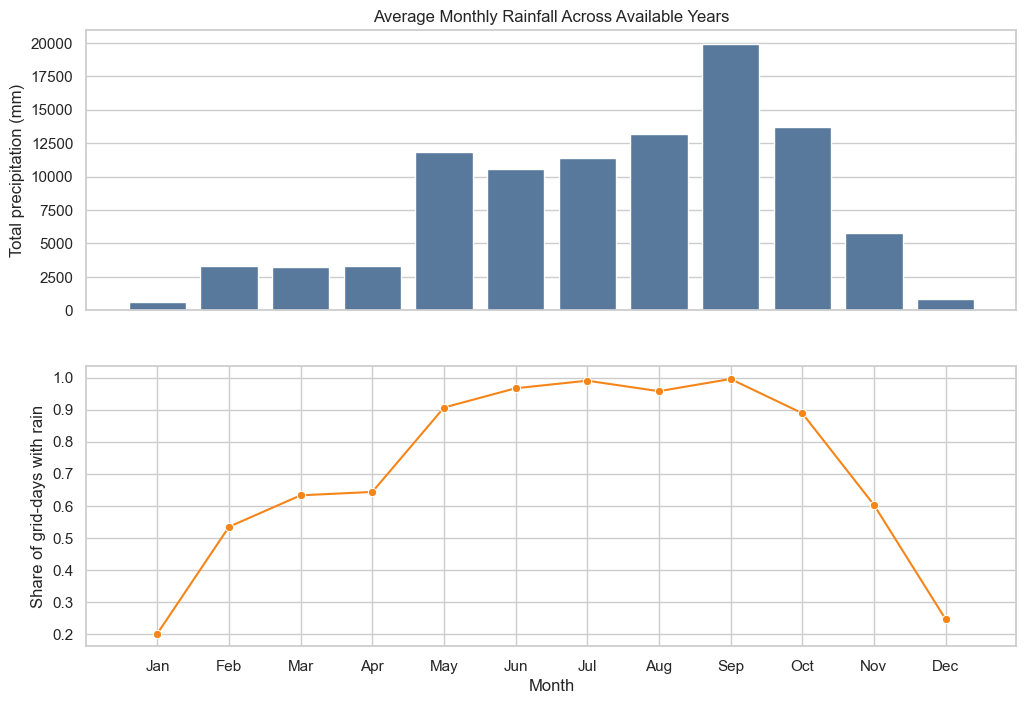

In [14]:
seasonal = monthly.groupby("month", as_index=False).agg(
    precipitation_sum_mean=("precipitation_sum", "mean"),
    rain_day_share_mean=("rain_day_share", "mean"),
    temp_mean=("temp_mean", "mean"),
    humidity_mean=("humidity_mean", "mean"),
)
seasonal["month_name"] = pd.to_datetime(seasonal["month"], format="%m").dt.month_name().str.slice(0, 3)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
sns.barplot(data=seasonal, x="month_name", y="precipitation_sum_mean", ax=axes[0], color="#4c78a8")
axes[0].set_title("Average Monthly Rainfall Across Available Years")
axes[0].set_ylabel("Total precipitation (mm)")
sns.lineplot(data=seasonal, x="month_name", y="rain_day_share_mean", marker="o", ax=axes[1], color="#f58518")
axes[1].set_ylabel("Share of grid-days with rain")
axes[1].set_xlabel("Month")
plt.show()

## 8. Hour Of Day Patterns

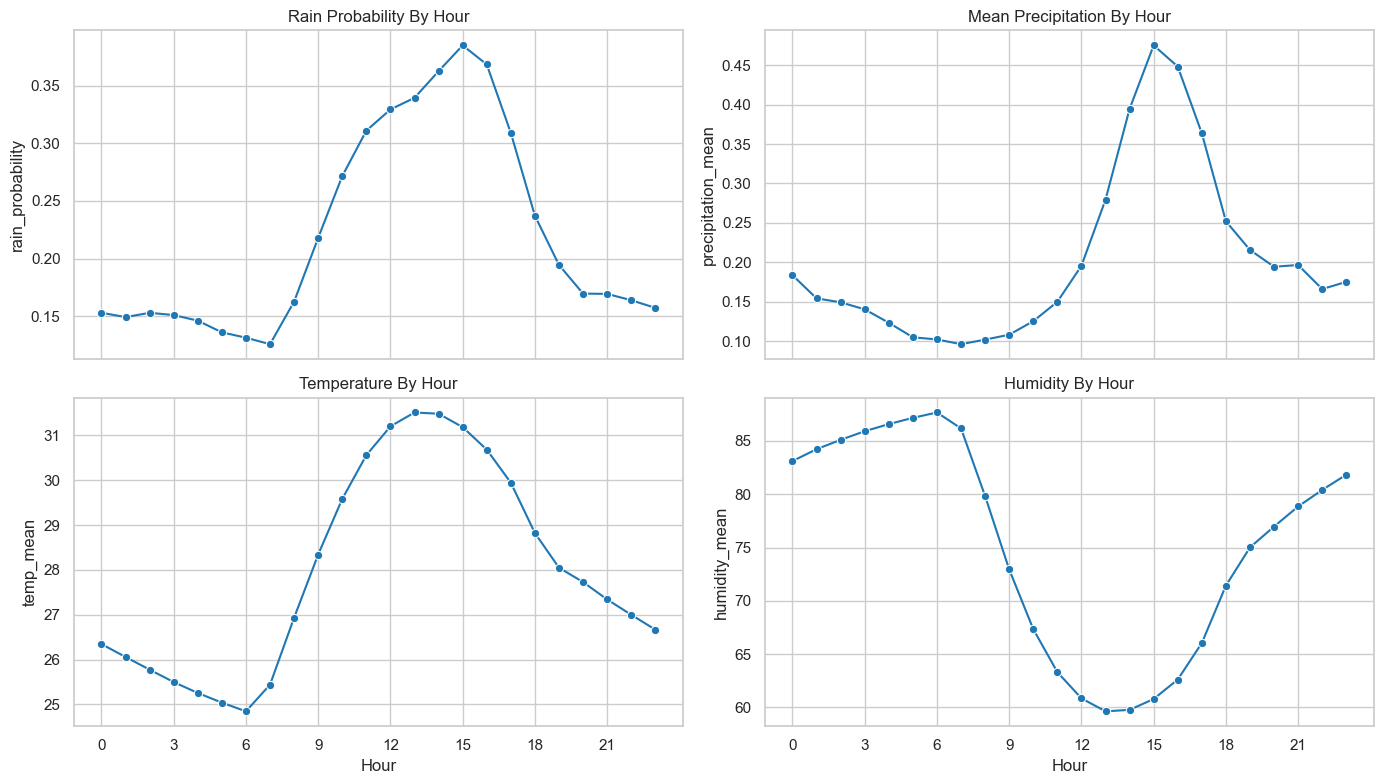

,hour,temp_mean,humidity_mean,cloud_cover_mean,wind_speed_mean,precipitation_mean,rain_probability
0,0,26.348,83.113,71.888,8.050,0.184,0.153
1,1,26.060,84.227,73.306,7.837,0.154,0.149
2,2,25.776,85.106,74.853,7.556,0.149,0.153
3,3,25.500,85.913,75.865,7.294,0.140,0.151
4,4,25.257,86.582,75.825,7.005,0.123,0.146
5,5,25.041,87.167,75.490,6.802,0.105,0.136
6,6,24.848,87.672,74.282,6.706,0.102,0.132
7,7,25.443,86.177,71.851,7.052,0.096,0.126
8,8,26.936,79.831,72.499,7.395,0.102,0.163
9,9,28.345,72.950,70.818,8.300,0.108,0.218


In [15]:
hourly_pattern = sql(f'''
SELECT
    EXTRACT(HOUR FROM local_forecast_time)::int AS hour,
    AVG(temperature_2m) AS temp_mean,
    AVG(relative_humidity_2m) AS humidity_mean,
    AVG(cloud_cover) AS cloud_cover_mean,
    AVG(wind_speed_10m) AS wind_speed_mean,
    AVG(precipitation) AS precipitation_mean,
    AVG((precipitation >= 0.1)::int) AS rain_probability
FROM {TABLE_NAME}
GROUP BY 1
ORDER BY 1;
''')

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
sns.lineplot(data=hourly_pattern, x="hour", y="rain_probability", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Rain Probability By Hour")
sns.lineplot(data=hourly_pattern, x="hour", y="precipitation_mean", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Mean Precipitation By Hour")
sns.lineplot(data=hourly_pattern, x="hour", y="temp_mean", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Temperature By Hour")
sns.lineplot(data=hourly_pattern, x="hour", y="humidity_mean", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Humidity By Hour")
for ax in axes.flat:
    ax.set_xlabel("Hour")
    ax.set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

hourly_pattern

## 9. Spatial Rainfall Differences

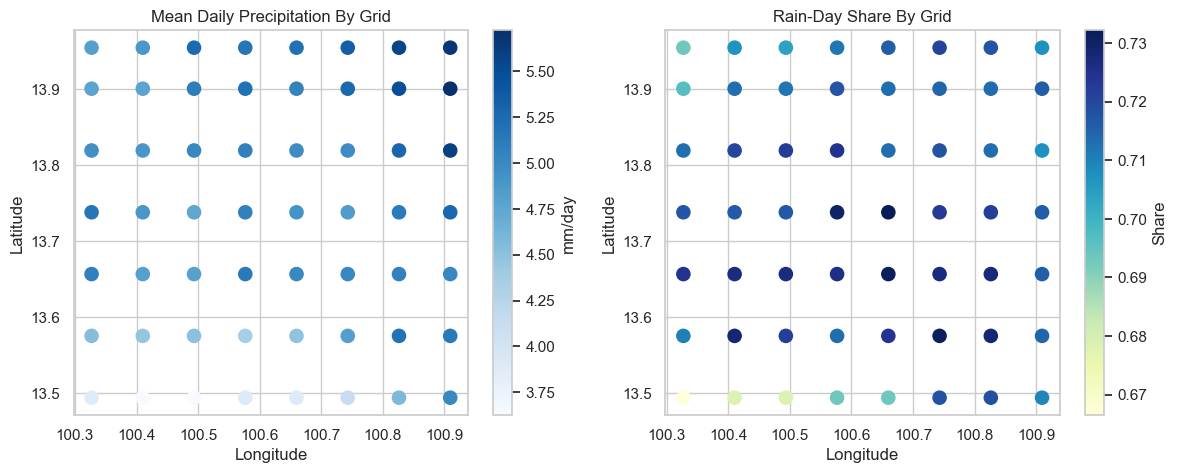

,grid_number,grid_row,grid_column,latitude,longitude,precipitation_daily_mean,precipitation_daily_total,rain_day_share,hourly_max
47,48,6,8,13.901,100.910,5.725,10453.800,0.716,21.600
55,56,7,8,13.955,100.910,5.660,10334.400,0.708,21.200
39,40,5,8,13.820,100.910,5.596,10218.200,0.708,24.800
54,55,7,7,13.955,100.826,5.561,10154.500,0.717,22.000
46,47,6,7,13.901,100.826,5.482,10010.400,0.714,20.400
53,54,7,6,13.955,100.743,5.341,9752.100,0.721,20.600
38,39,5,7,13.820,100.826,5.285,9651.000,0.713,21.200
45,46,6,6,13.901,100.743,5.269,9620.300,0.715,23.600
31,32,4,8,13.738,100.910,5.268,9618.800,0.716,25.500
50,51,7,3,13.955,100.493,5.245,9577.400,0.704,24.200


In [16]:
grid_rain = daily.groupby(
    ["grid_number", "grid_row", "grid_column", "latitude", "longitude"],
    as_index=False,
).agg(
    precipitation_daily_mean=("precipitation_sum", "mean"),
    precipitation_daily_total=("precipitation_sum", "sum"),
    rain_day_share=("is_rain_day", "mean"),
    hourly_max=("precipitation_hourly_max", "max"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc1 = axes[0].scatter(grid_rain["longitude"], grid_rain["latitude"], c=grid_rain["precipitation_daily_mean"], cmap="Blues", s=90)
axes[0].set_title("Mean Daily Precipitation By Grid")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc1, ax=axes[0], label="mm/day")

sc2 = axes[1].scatter(grid_rain["longitude"], grid_rain["latitude"], c=grid_rain["rain_day_share"], cmap="YlGnBu", s=90)
axes[1].set_title("Rain-Day Share By Grid")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(sc2, ax=axes[1], label="Share")
plt.show()

grid_rain.sort_values("precipitation_daily_mean", ascending=False).head(10)

## 10. Correlations With Rain

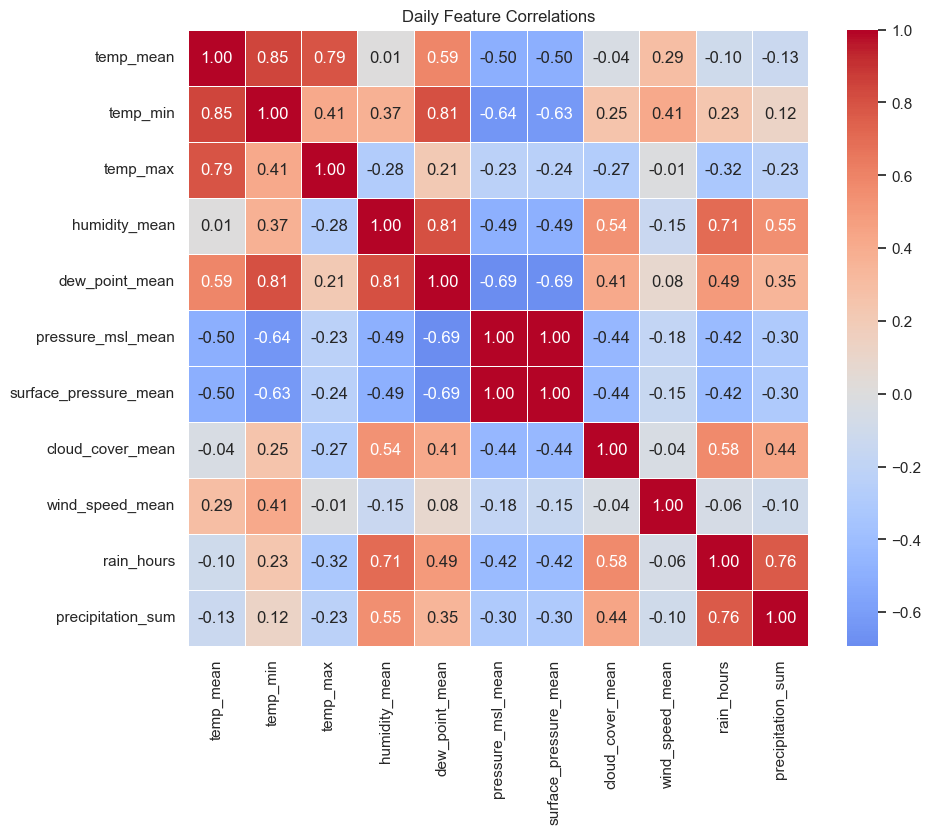

precipitation_sum        1.000
rain_hours               0.763
humidity_mean            0.550
cloud_cover_mean         0.440
dew_point_mean           0.348
temp_min                 0.121
wind_speed_mean         -0.098
temp_mean               -0.131
temp_max                -0.230
pressure_msl_mean       -0.301
surface_pressure_mean   -0.302
Name: precipitation_sum, dtype: float64

In [17]:
corr_columns = [
    "temp_mean",
    "temp_min",
    "temp_max",
    "humidity_mean",
    "dew_point_mean",
    "pressure_msl_mean",
    "surface_pressure_mean",
    "cloud_cover_mean",
    "wind_speed_mean",
    "rain_hours",
    "precipitation_sum",
]

corr = daily[corr_columns].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Daily Feature Correlations")
plt.show()

corr["precipitation_sum"].sort_values(ascending=False)

## 11. Rain Thresholds

Use this to choose a rainfall threshold for classification targets.

In [18]:
thresholds = [0.1, 0.5, 1, 2, 5, 10, 20]
threshold_summary = pd.DataFrame({
    "threshold_mm_day": thresholds,
    "grid_day_share": [(daily["precipitation_sum"] >= threshold).mean() for threshold in thresholds],
    "city_day_share_any_grid": [
        (daily.assign(hit=daily["precipitation_sum"] >= threshold).groupby("date")["hit"].max()).mean()
        for threshold in thresholds
    ],
})
threshold_summary

,threshold_mm_day,grid_day_share,city_day_share_any_grid
0,0.100,0.715,0.840
1,0.500,0.605,0.781
2,1.000,0.532,0.732
3,2.000,0.451,0.670
4,5.000,0.316,0.556
5,10.000,0.176,0.424
6,20.000,0.054,0.214


## 12. Save Analysis Extracts

Optional exports for modelling or charting outside the notebook.

In [19]:
OUTPUT_DIR = "om_bkk_analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

daily.to_csv(os.path.join(OUTPUT_DIR, "om_bkk_daily_by_grid.csv"), index=False)
city_daily.to_csv(os.path.join(OUTPUT_DIR, "om_bkk_city_daily.csv"), index=False)
monthly.to_csv(os.path.join(OUTPUT_DIR, "om_bkk_monthly.csv"), index=False)
grid_rain.to_csv(os.path.join(OUTPUT_DIR, "om_bkk_grid_rain_summary.csv"), index=False)

print(f"Saved outputs to {OUTPUT_DIR}")

Saved outputs to om_bkk_analysis_outputs


In [20]:
conn.close()
print("Connection closed")

Connection closed
